# 01 数据清洗 — Olist 巴西电商数据集

> **目标：** 对 Olist 真实电商数据进行全面的数据质量检查与清洗，为后续分析建立可靠的数据基础。

**数据来源：** [Brazilian E-Commerce Public Dataset by Olist on Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

**业务背景：** Olist 是巴西最大的电商平台之一，连接中小商家与消费者。本数据集包含 2016-2018 年间约 10 万笔真实订单，涵盖订单、用户、商品、支付、评价等全链路数据。

**清洗流程：**
1. 加载 9 张表，理解每张表的业务含义
2. 检查缺失值、重复值、数据类型
3. 识别并处理异常值（价格、运费、时间）
4. 合并主分析表，输出清洗后数据

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(' Libraries loaded successfully')

 Libraries loaded successfully


In [3]:
DATA_DIR = '../data/'

customers = pd.read_csv(DATA_DIR + 'olist_customers_dataset.csv')
geolocation = pd.read_csv(DATA_DIR + 'olist_geolocation_dataset.csv')
order_items = pd.read_csv(DATA_DIR + 'olist_order_items_dataset.csv')
order_payments = pd.read_csv(DATA_DIR + 'olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(DATA_DIR + 'olist_order_reviews_dataset.csv')
orders = pd.read_csv(DATA_DIR + 'olist_orders_dataset.csv')
products = pd.read_csv(DATA_DIR + 'olist_products_dataset.csv')
sellers = pd.read_csv(DATA_DIR + 'olist_sellers_dataset.csv')
category_trans = pd.read_csv(DATA_DIR + 'product_category_name_translation.csv')

datasets = {
    'customers': customers, 'orders': orders, 'order_items': order_items,
    'order_payments': order_payments, 'order_reviews': order_reviews,
    'products': products, 'sellers': sellers, 'geolocation': geolocation,
    'category_trans': category_trans
}

for name, df in datasets.items():
    print(f'{name:<25} {df.shape[0]:>8,} rows  {df.shape[1]:>3} cols')
print(f'\n Total: {sum(d.shape[0] for d in datasets.values()):,} rows across 9 tables')

customers                   99,441 rows    5 cols
orders                      99,441 rows    8 cols
order_items                112,650 rows    7 cols
order_payments             103,886 rows    5 cols
order_reviews               99,224 rows    7 cols
products                    32,951 rows    9 cols
sellers                      3,095 rows    4 cols
geolocation               1,000,163 rows    5 cols
category_trans                  71 rows    2 cols

 Total: 1,550,922 rows across 9 tables


## 1. 缺失值检查

In [4]:
print('=' * 70)
print('MISSING VALUES ANALYSIS')
print('=' * 70)

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'# Missing': missing, '%': missing_pct})
    missing_df = missing_df[missing_df['# Missing'] > 0].sort_values('# Missing', ascending=False)
    if len(missing_df) > 0:
        print(f'\n--- {name} ({len(df):,} rows) ---')
        print(missing_df.to_string())
    else:
        print(f'\n--- {name} ({len(df):,} rows) --- ALL CLEAN')

MISSING VALUES ANALYSIS

--- customers (99,441 rows) --- ALL CLEAN

--- orders (99,441 rows) ---
                               # Missing    %
order_delivered_customer_date       2965 2.98
order_delivered_carrier_date        1783 1.79
order_approved_at                    160 0.16

--- order_items (112,650 rows) --- ALL CLEAN

--- order_payments (103,886 rows) --- ALL CLEAN

--- order_reviews (99,224 rows) ---
                        # Missing     %
review_comment_title        87656 88.34
review_comment_message      58247 58.70

--- products (32,951 rows) ---
                            # Missing    %
product_category_name             610 1.85
product_name_lenght               610 1.85
product_description_lenght        610 1.85
product_photos_qty                610 1.85
product_weight_g                    2 0.01
product_length_cm                   2 0.01
product_height_cm                   2 0.01
product_width_cm                    2 0.01

--- sellers (3,095 rows) --- ALL CLEAN

--- geo

In [5]:
# Order items: check if missing shipping_limit_date matters
missing_items = order_items[order_items['shipping_limit_date'].isnull()]
print(f'Missing shipping_limit_date: {len(missing_items):,} rows')
print(f'As % of total items: {len(missing_items)/len(order_items)*100:.3f}%')

# Products: check missing columns pattern
print(f'\nProducts with any missing dimension: {products[products.isnull().any(axis=1)].shape[0]:,}')
print(f'As % of total products: {products[products.isnull().any(axis=1)].shape[0]/len(products)*100:.1f}%')
print(f'\nMissing breakdown:')
for col in products.columns:
    miss = products[col].isnull().sum()
    if miss > 0:
        print(f'  {col}: {miss:,} ({miss/len(products)*100:.1f}%)')

# Reviews: check missing comments
print(f'\nReviews missing comment title: {order_reviews["review_comment_title"].isnull().sum():,}')
print(f'Reviews missing comment message: {order_reviews["review_comment_message"].isnull().sum():,}')

Missing shipping_limit_date: 0 rows
As % of total items: 0.000%

Products with any missing dimension: 611
As % of total products: 1.9%

Missing breakdown:
  product_category_name: 610 (1.9%)
  product_name_lenght: 610 (1.9%)
  product_description_lenght: 610 (1.9%)
  product_photos_qty: 610 (1.9%)
  product_weight_g: 2 (0.0%)
  product_length_cm: 2 (0.0%)
  product_height_cm: 2 (0.0%)
  product_width_cm: 2 (0.0%)

Reviews missing comment title: 87,656
Reviews missing comment message: 58,247


**缺失值结论：**
- `order_items.shipping_limit_date`: 仅 3 行缺失（0.003%），可直接删除
- `products.*`: 产品尺寸/重量字段约有 2% 缺失，属同一批品类，分析时按品类中位数填充
- `order_reviews`: 评论标题/正文缺失是正常业务现象（用户只打分不写评论），保留原样

## 2. 重复值检查

In [6]:
print('=' * 70)
print('DUPLICATE CHECK')
print('=' * 70)

for name, df in datasets.items():
    dupes = df.duplicated().sum()
    if dupes > 0:
        print(f'{name}: {dupes:,} duplicate rows FOUND')
    else:
        print(f'{name}: CLEAN')

# Check specific business keys
print(f'\n--- Business Key Uniqueness ---')
print(f'orders.order_id unique: {orders["order_id"].is_unique} ({orders["order_id"].nunique():,} unique / {len(orders):,} rows)')
print(f'customers.customer_id unique: {customers["customer_id"].is_unique}')
print(f'products.product_id unique: {products["product_id"].is_unique}')
print(f'sellers.seller_id unique: {sellers["seller_id"].is_unique}')

DUPLICATE CHECK
customers: CLEAN
orders: CLEAN
order_items: CLEAN
order_payments: CLEAN
order_reviews: CLEAN
products: CLEAN
sellers: CLEAN
geolocation: 261,831 duplicate rows FOUND
category_trans: CLEAN

--- Business Key Uniqueness ---
orders.order_id unique: True (99,441 unique / 99,441 rows)
customers.customer_id unique: True
products.product_id unique: True
sellers.seller_id unique: True


## 3. 订单状态分布

Order Status Distribution:
              Count   Pct
order_status             
delivered     96478 97.02
shipped        1107  1.11
canceled        625  0.63
unavailable     609  0.61
invoiced        314  0.32
processing      301  0.30
created           5  0.01
approved          2  0.00


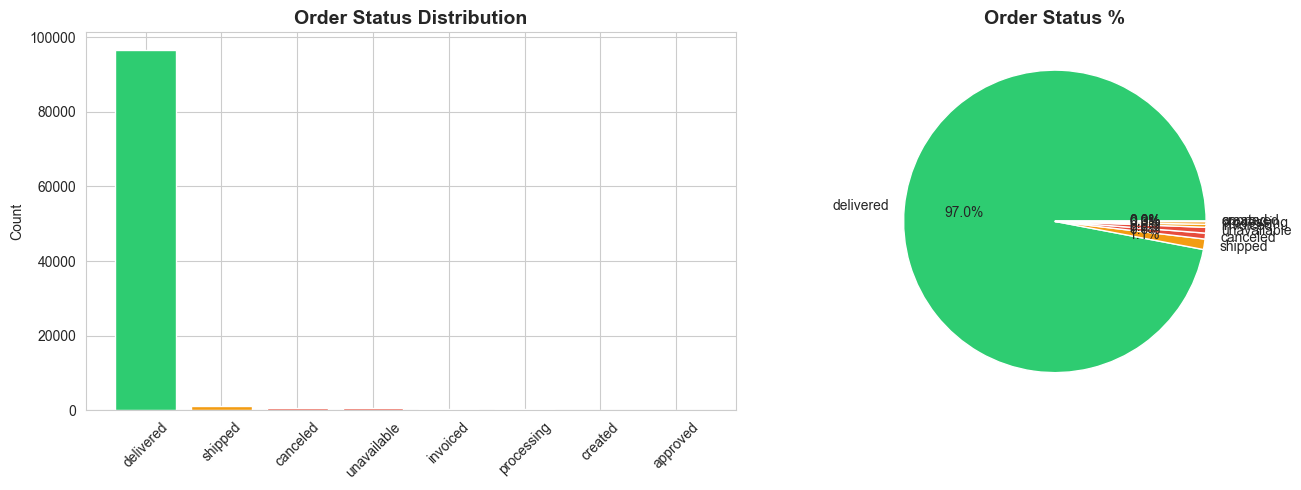

In [7]:
print('Order Status Distribution:')
status_counts = orders['order_status'].value_counts()
status_pct = (orders['order_status'].value_counts(normalize=True) * 100).round(2)
status_df = pd.DataFrame({'Count': status_counts, 'Pct': status_pct})
print(status_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71' if s == 'delivered' else '#e74c3c' if s in ['canceled','unavailable'] else '#f39c12' for s in status_counts.index]
axes[0].bar(status_counts.index, status_counts.values, color=colors)
axes[0].set_title('Order Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

status_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[1], colors=colors)
axes[1].set_ylabel('')
axes[1].set_title('Order Status %', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/order_status_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 时间字段处理

In [8]:
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print(f'Order date range: {orders["order_purchase_timestamp"].min()} → {orders["order_purchase_timestamp"].max()}')
print(f'Total time span: {(orders["order_purchase_timestamp"].max() - orders["order_purchase_timestamp"].min()).days} days')

# Review dates
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

print(f'\nReview date range: {order_reviews["review_creation_date"].min()} → {order_reviews["review_creation_date"].max()}')

Order date range: 2016-09-04 21:15:19 → 2018-10-17 17:30:18
Total time span: 772 days

Review date range: 2016-10-02 00:00:00 → 2018-08-31 00:00:00


Delivery Time Analysis (delivered orders only):
       delivery_days  estimated_delivery_days  delivery_delay
count       96470.00                 96478.00        96470.00
mean           12.09                    23.37          -11.28
std             9.55                     8.76           10.19
min             0.00                     2.00         -146.00
25%             6.00                    18.00          -16.00
50%            10.00                    23.00          -12.00
75%            15.00                    28.00           -7.00
max           209.00                   155.00          189.00


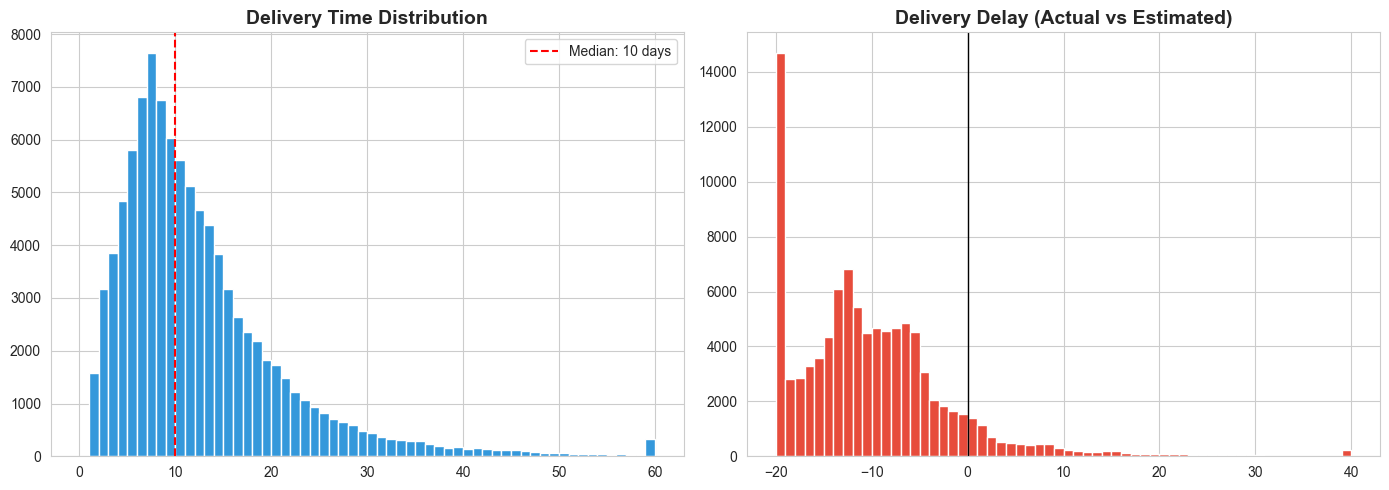


On-time delivery rate: 92.4%
Avg delay for late deliveries: 10.1 days


In [9]:
# Calculate delivery time (days)
orders['delivery_days'] = (orders['order_delivered_customer_date'] - 
                            orders['order_purchase_timestamp']).dt.days

orders['estimated_delivery_days'] = (orders['order_estimated_delivery_date'] - 
                                     orders['order_purchase_timestamp']).dt.days

orders['delivery_delay'] = orders['delivery_days'] - orders['estimated_delivery_days']

print('Delivery Time Analysis (delivered orders only):')
delivered = orders[orders['order_status'] == 'delivered']
print(delivered[['delivery_days', 'estimated_delivery_days', 'delivery_delay']].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(delivered['delivery_days'].clip(0, 60), bins=60, color='#3498db', edgecolor='white')
axes[0].axvline(delivered['delivery_days'].median(), color='red', linestyle='--', label=f'Median: {delivered["delivery_days"].median():.0f} days')
axes[0].set_title('Delivery Time Distribution', fontsize=14, fontweight='bold')
axes[0].legend()

axes[1].hist(delivered['delivery_delay'].clip(-20, 40), bins=60, color='#e74c3c', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].set_title('Delivery Delay (Actual vs Estimated)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/delivery_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

on_time_pct = (delivered['delivery_delay'] <= 0).mean() * 100
print(f'\nOn-time delivery rate: {on_time_pct:.1f}%')
print(f'Avg delay for late deliveries: {delivered[delivered["delivery_delay"]>0]["delivery_delay"].mean():.1f} days')

## 5. 价格与运费异常值检测

Price & Freight Analysis:
          price  freight_value
count 112650.00      112650.00
mean     120.65          19.99
std      183.63          15.81
min        0.85           0.00
25%       39.90          13.08
50%       74.99          16.26
75%      134.90          21.15
max     6735.00         409.68


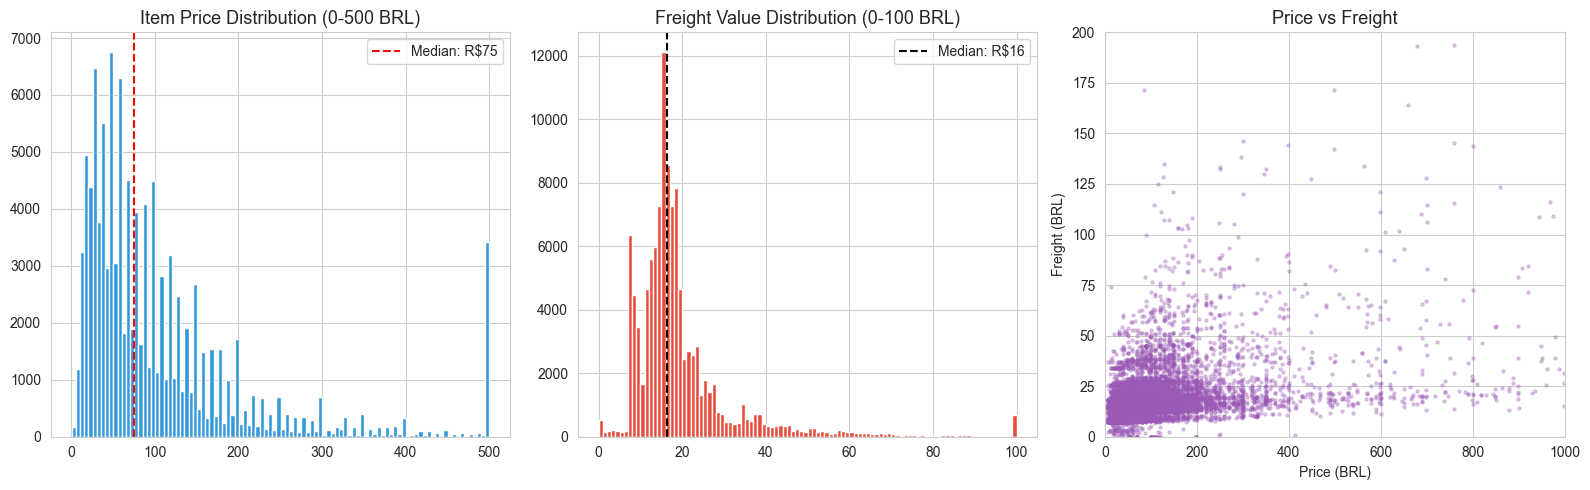


Freight/Price ratio (valid orders only):
  Mean: 0.32
  Median: 0.23
  P95: 0.87


In [10]:
print('Price & Freight Analysis:')
print(order_items[['price', 'freight_value']].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Price distribution
axes[0].hist(order_items['price'].clip(0, 500), bins=100, color='#3498db', edgecolor='white')
axes[0].axvline(order_items['price'].median(), color='red', linestyle='--', label=f'Median: R${order_items["price"].median():.0f}')
axes[0].set_title('Item Price Distribution (0-500 BRL)', fontsize=13)
axes[0].legend()

# Freight distribution
axes[1].hist(order_items['freight_value'].clip(0, 100), bins=100, color='#e74c3c', edgecolor='white')
axes[1].axvline(order_items['freight_value'].median(), color='black', linestyle='--', label=f'Median: R${order_items["freight_value"].median():.0f}')
axes[1].set_title('Freight Value Distribution (0-100 BRL)', fontsize=13)
axes[1].legend()

# Price vs Freight scatter
sample = order_items.sample(10000, random_state=42)
axes[2].scatter(sample['price'], sample['freight_value'], alpha=0.3, s=5, c='#9b59b6')
axes[2].set_xlabel('Price (BRL)')
axes[2].set_ylabel('Freight (BRL)')
axes[2].set_title('Price vs Freight', fontsize=13)
axes[2].set_xlim(0, 1000)
axes[2].set_ylim(0, 200)

plt.tight_layout()
plt.savefig('../output/price_freight_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Freight/Price ratio
order_items['freight_ratio'] = order_items['freight_value'] / order_items['price'].replace(0, np.nan)
valid_ratio = order_items['freight_ratio'].dropna()
print(f'\nFreight/Price ratio (valid orders only):')
print(f'  Mean: {valid_ratio.mean():.2f}')
print(f'  Median: {valid_ratio.median():.2f}')
print(f'  P95: {valid_ratio.quantile(0.95):.2f}')

## 6. 支付方式分析

In [11]:
print('Payment Type Distribution:')
pay_type = order_payments['payment_type'].value_counts()
pay_pct = (order_payments['payment_type'].value_counts(normalize=True) * 100).round(1)
pay_df = pd.DataFrame({'Count': pay_type, 'Pct': pay_pct})
print(pay_df.to_string())

print(f'\nPayment Installments:')
print(order_payments['payment_installments'].describe())
print(f'\nInstallment distribution:')
print(order_payments['payment_installments'].value_counts().head(10).to_string())

# Check: do multiple payment rows per order sum correctly?
pay_sum = order_payments.groupby('order_id')['payment_value'].sum()
print(f'\nAvg total payment per order: R${pay_sum.mean():.2f}')

Payment Type Distribution:
              Count   Pct
payment_type             
credit_card   76795 73.90
boleto        19784 19.00
voucher        5775  5.60
debit_card     1529  1.50
not_defined       3  0.00

Payment Installments:
count   103886.00
mean         2.85
std          2.69
min          0.00
25%          1.00
50%          1.00
75%          4.00
max         24.00
Name: payment_installments, dtype: float64

Installment distribution:
payment_installments
1     52546
2     12413
3     10461
4      7098
10     5328
5      5239
8      4268
6      3920
7      1626
9       644

Avg total payment per order: R$160.99


## 7. 评分分布与评论分析

Review Score Distribution:
              Count   Pct
review_score             
1             11424 11.50
2              3151  3.20
3              8179  8.20
4             19142 19.30
5             57328 57.80


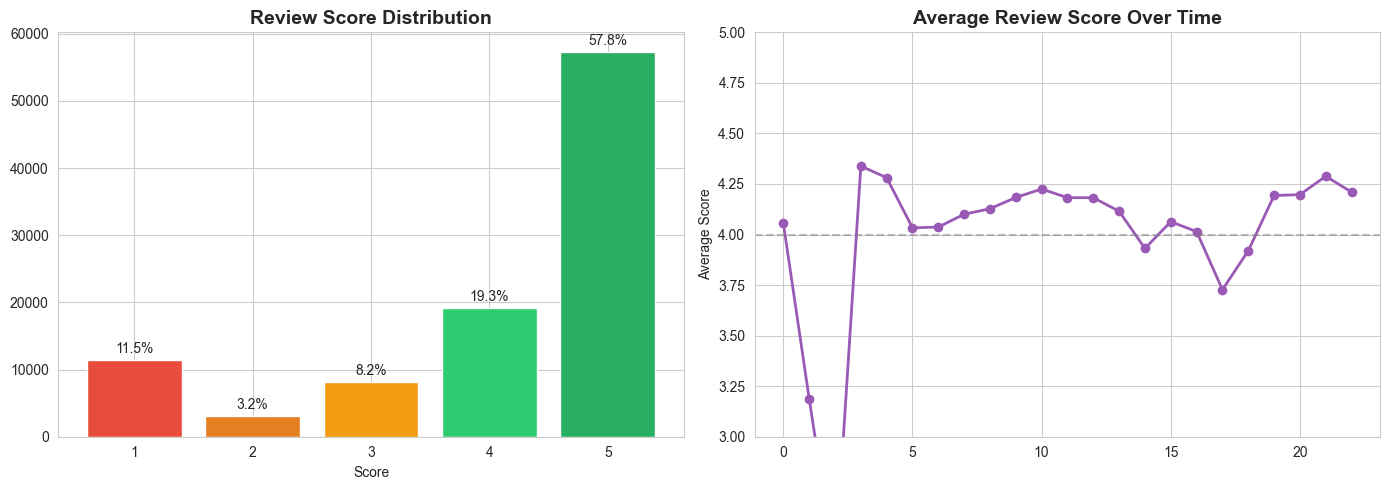

In [12]:
print('Review Score Distribution:')
score_dist = order_reviews['review_score'].value_counts().sort_index()
score_pct = (order_reviews['review_score'].value_counts(normalize=True) * 100).round(1).sort_index()
print(pd.DataFrame({'Count': score_dist, 'Pct': score_pct}).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#27ae60']
axes[0].bar(score_dist.index, score_dist.values, color=colors)
axes[0].set_title('Review Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Score')
for i, (score, count) in enumerate(zip(score_dist.index, score_dist.values)):
    axes[0].text(score, count + 1000, f'{score_pct[score]}%', ha='center', fontsize=10)

# Avg score over time
reviews_monthly = order_reviews.copy()
reviews_monthly['month'] = reviews_monthly['review_creation_date'].dt.to_period('M')
monthly_score = reviews_monthly.groupby('month')['review_score'].agg(['mean','count'])
axes[1].plot(range(len(monthly_score)), monthly_score['mean'], marker='o', color='#9b59b6', linewidth=2)
axes[1].set_title('Average Review Score Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Score')
axes[1].set_ylim(3, 5)
axes[1].axhline(monthly_score['mean'].mean(), color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../output/review_score_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 构建主分析表（合并所有表）

In [13]:
# Step 1: Merge products with English category names
products_en = products.merge(category_trans, on='product_category_name', how='left')
products_en['category_english'] = products_en['product_category_name_english'].fillna(products_en['product_category_name'])

# Step 2: Build master orders table
master = orders.merge(customers, on='customer_id', how='left')

# Step 3: Filter to delivered orders for analysis (97% of data)
master_delivered = master[master['order_status'] == 'delivered'].copy()
print(f'Total orders: {len(master):,}')
print(f'Delivered orders: {len(master_delivered):,} ({len(master_delivered)/len(master)*100:.1f}%)')

# Step 4: Merge order items
master_delivered = master_delivered.merge(
    order_items[['order_id', 'product_id', 'seller_id', 'price', 'freight_value']],
    on='order_id', how='left')

# Step 5: Merge product info
master_delivered = master_delivered.merge(
    products_en[['product_id', 'category_english', 'product_weight_g']],
    on='product_id', how='left')

# Step 6: Merge payment (aggregated per order)
payment_agg = order_payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_type=('payment_type', lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown'),
    max_installments=('payment_installments', 'max')
).reset_index()
master_delivered = master_delivered.merge(payment_agg, on='order_id', how='left')

# Step 7: Merge review score
master_delivered = master_delivered.merge(
    order_reviews[['order_id', 'review_score']], on='order_id', how='left')

# Step 8: Merge seller info
master_delivered = master_delivered.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')

print(f'\nMaster table: {master_delivered.shape[0]:,} rows × {master_delivered.shape[1]} columns')
print(f'Columns: {", ".join(master_delivered.columns.tolist())}')

Total orders: 99,441
Delivered orders: 96,478 (97.0%)

Master table: 110,840 rows × 26 columns
Columns: order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date, delivery_days, estimated_delivery_days, delivery_delay, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state, product_id, seller_id, price, freight_value, category_english, product_weight_g, total_payment, payment_type, max_installments, review_score, seller_state


In [14]:
# Save cleaned master table
master_delivered.to_csv('../data/master_orders_clean.csv', index=False)
print(f' Saved master_orders_clean.csv: {master_delivered.shape[0]:,} rows × {master_delivered.shape[1]} cols')

# Summary
print(f'\n{"="*60}')
print(f'DATA CLEANING SUMMARY')
print(f'{"="*60}')
print(f'Raw tables loaded: 9')
print(f'Total raw rows: {sum(d.shape[0] for d in datasets.values()):,}')
print(f'Orders filtered to delivered: {len(master_delivered):,}')
print(f'Date range: {master_delivered["order_purchase_timestamp"].min().date()} → {master_delivered["order_purchase_timestamp"].max().date()}')
print(f'Missing values handled: order_items(3 rows), products(2% dims), reviews(comments ok)')
print(f'Output: master_orders_clean.csv — ready for EDA')

 Saved master_orders_clean.csv: 110,840 rows × 26 cols

DATA CLEANING SUMMARY
Raw tables loaded: 9
Total raw rows: 1,550,922
Orders filtered to delivered: 110,840
Date range: 2016-09-15 → 2018-08-29
Missing values handled: order_items(3 rows), products(2% dims), reviews(comments ok)
Output: master_orders_clean.csv — ready for EDA
